In [5]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение функций fft, fftfreq
from scipy.fft import fft

In [ ]:
# Ячейка № 2

# задание функции, возвращающей
# True, если точка является
# неподвижной точкой отображения,
# задаваемого функцией z^2, и
# False, если данная начальная
# точка не является неподвижной
def Is_Mandelbrot(C, N_Iterations):
    # входные переменные:
    # C - массив, содержащий значения
    #     координат точек, проверяемых
    #     на неподвижность
    # N_Iteration - число итераций
    z = 0
    for _ in range(N_Iterations):
        z = z**2 + C
        if abs(z) > 2:
            # точка не явялется неподвижной
            return False
    # точка является неподвижной
    return True

In [7]:
# Ячейка № 3

# задание функции, возвращающей
# значения координат точек изображения,
# проверяемых далее на их принадлежность
# множеству Мандельброта
def Candidate_Values(X_min, X_max, Y_min, Y_max, Pixel_Density):
    # входные переменные:
    # X_min, X_max, Y_min, Y_max - значения координат
    #                              вершин прямоугольника,
    #                              используемого для визуализации
    #                              множества Мандельброта
    # Pixel_Density - число пикселей изображения
    #                 множества Мандельброта
    #                 по каждой из координатных осей
    #                 (число пиклелей изображения
    #                 множества Мандельброта равно
    #                 Pixel_Density х Pixel_Density)

    # задание значений абсцисс
    # координатной сетки c шагом 1/Pixel_Density
    Real = np.linspace(X_min, X_max, num=int((X_max - X_min) * Pixel_Density))

    # задание значений ординат
    # координатной сетки c шагом 1/Pixel_Density
    Imag = np.linspace(Y_min, Y_max, num=int((Y_max - Y_min) * Pixel_Density))

    # создание матриц Xx, Yy
    Xx, Yy = np.meshgrid(Real, Imag)

    # создание матрицы, содержащей координаты
    # точек комплексной плоскости, проверяемых
    # далее на принадлежность множеству
    # Мандельброта
    M = Xx + 1j * Yy

    return M

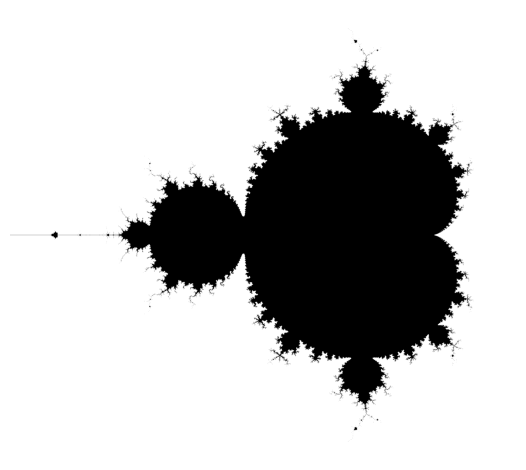

In [8]:
# Ячейка № 4

# задание значений координат
# вершин прямоугольника,
# используемого для визуализации
# множества Мандельброта
X_min = -2
X_max = 0.7
Y_min = -1.2
Y_max = 1.2

# задание числа пикселей изображения
# множества Мандельброта по каждой
# из координатных осей
# (число пикселей изображения
# множества Мандельброта
#  равно Pixel_Density х Pixel_Density)
Pixel_Density = 1024

# задание числа итераций
# отображения, задаваемого
# функцией z^2
N_Iterations = 30

# задание значений
# координат точек комплексной плоскости,
# проверяемых далее на их принадлежность
# множеству Мандельброта
C = Candidate_Values(X_min, X_max, Y_min, Y_max, Pixel_Density)

# проверка точек
# комплексной плоскости,
# их принадлежность
# множеству Мандельброта
# и формирование маски изображения
# данного множества
Mandelbrot_Mask = np.vectorize(Is_Mandelbrot)(C, N_Iterations=N_Iterations)

# визуализация множества Мандельброта
plt.imshow(Mandelbrot_Mask, cmap="binary")
plt.gca().set_aspect("equal")
plt.axis("off")
plt.tight_layout()

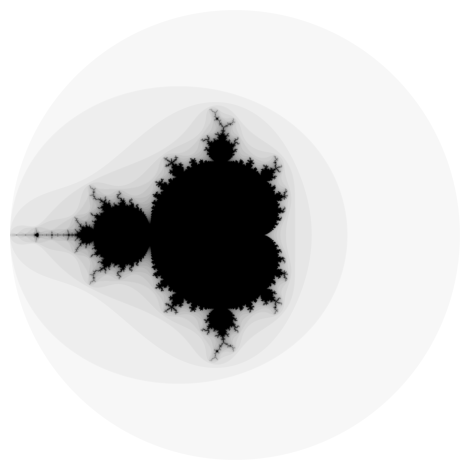

In [9]:
# ячейка № 5

# отключение вывода сообщений
# о появлении значений переменных,
# больших предельно допустимого значения
np.seterr(invalid="ignore")

# задание длины стороны
# квадратной области,
# в которой далее строятся
# изображения множества Мандельброта и
# граничных множеств
DL = 2

# задание числа итераций
N_iter = 30

# задание числа пикселей изображения
# множества Мандельброта по каждой
# из координатных осей
# (число пикселей изображения
# множества Мандельброта
#  равно Pixel_Density х Pixel_Density)
Pixel_Dencity = 1024

# задание значений абсцисс
# координатной сетки шагом 1/Pixel_Density
x = np.linspace(-DL, DL, int(2 * DL * Pixel_Dencity))

# задание значений ординат
# координатной сетки c шагом 1/Pixel_Density
y = np.linspace(-DL, DL, int(2 * DL * Pixel_Dencity))

# создание матриц X, Y
X, Y = np.meshgrid(x, y)

# создание матрицы C, содержащей координаты
# точек комплексной плоскости, проверяемых
# далее на принадлежность множеству
# Мандельброта
C = X + Y * 1j

# инициализация двумерных массивов B, Z
B = np.zeros(int(2 * DL * Pixel_Dencity))
Z = np.zeros(int(2 * DL * Pixel_Dencity))

# вычисление значений координат
# итерируемых точек
# комплексной плоскости
for i in range(N_iter):
    # если |z|<2 размещение в массиве Z
    # итерированное значение числа Z,
    # иначе nan
    Z = np.where(np.abs(Z) < 2, Z**2 + C, np.nan)

    # размещение в массиве B,
    # значений комплексных
    # комплексных чисел,
    # удовлетворяющих условию |z|<2
    B = B + (np.abs(Z) < 2)

# визуализация множества Мандельброта
# и его граничных множеств
plt.imshow(B, cmap="binary", extent=[0, 0.5, 0, 0.5])

plt.gca().set_aspect("equal")
plt.axis("off")
plt.tight_layout()
plt.show()

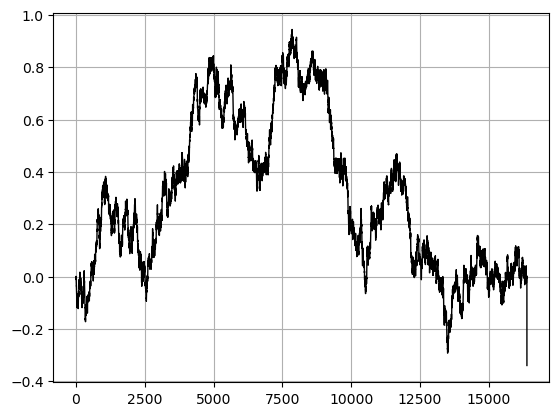

In [10]:
import random

random.seed()

Level = 14
Sigma = 1
Ratio = 0.5
N = 2**Level
X = np.zeros(N + 1)


X[N] = Ratio * Sigma * random.gauss(0, Sigma)

for i in range(1, Level + 1):
    if i == 1:
        Number = np.array([N / 2**i, N / 2 ** (i - 1), 0], dtype=int)
        # print(Number)
        X[Number[0]] = 0.5 * (X[Number[2]] + X[Number[1]]) + Ratio ** (
            (i + 1) / 2
        ) * Sigma * random.gauss(0, Sigma)

    if i == 2:
        for m in range(1, i):
            Number = np.array(
                [
                    (2 * m - 1) * N / 2**i,
                    m * N / 2 ** (i - 1),
                    (m - 1) * N / 2 ** (i - 1),
                ],
                dtype=int,
            )
            # print(Number)
            X[Number[0]] = 0.5 * (X[Number[1]] + X[Number[2]]) + Ratio ** (
                (i + 1) / 2
            ) * Sigma * random.gauss(0, Sigma)

    if i > 2:
        for m in range(1, 2 ** (i - 1)):
            Number = np.array(
                [
                    (2 * m - 1) * N / 2**i,
                    m * N / 2 ** (i - 1),
                    (m - 1) * N / 2 ** (i - 1),
                ],
                dtype=int,
            )

            X[Number[0]] = 0.5 * (X[Number[1]] + X[Number[2]]) + Ratio ** (
                (i + 1) / 2
            ) * Sigma * random.gauss(0, Sigma)


plt.plot(X, "-k", lw=1)
plt.grid("True")
plt.show()

In [11]:
def Divide2Part(X, Ratio, Sigma, Std, I0, I2, Level, Max_Level):
    I1 = (I0 + I2) // 2
    X[I1] = 0.5 * (X[I0] + X[I2]) + Std * Sigma * random.gauss(0, Sigma)
    if Level <= Max_Level - 1:
        Std_mid = Ratio ** ((Level + 1) / 2)
        X = Divide2Part(X, Ratio, Sigma, Std_mid, I0, I1, Level + 1, Max_Level)
        X = Divide2Part(X, Ratio, Sigma, Std_mid, I1, I2, Level + 1, Max_Level)
    return X

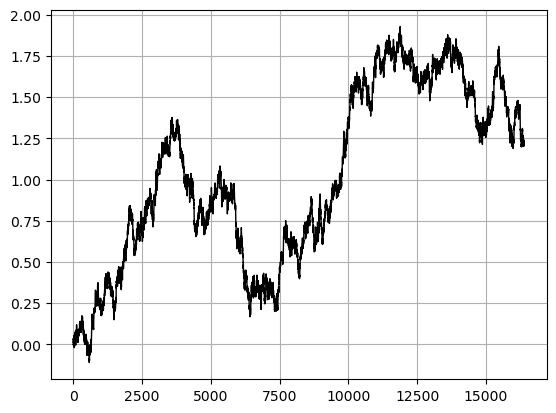

In [12]:
import random

random.seed()
Max_Level = 14
Sigma = 1
Level = 1
N = 2**Max_Level
Ratio = 0.5
Std = Sigma * Ratio

X = np.zeros(N + 1)

X[N] = Sigma * random.gauss(0, Sigma)

I0 = 0
I2 = N

X = Divide2Part(X, Ratio, Sigma, Std, I0, I2, Level, Max_Level)

plt.plot(X, "-k", lw=1)
plt.grid("True")
plt.show()

In [13]:
def FBM_FF(H, Level):
    N = 2**Level
    X = np.zeros(N) * 1j
    X[0] = random.gauss(0, 1)
    for i in range(1, N // 2 - 1):
        Tmp = random.gauss(0, 1) * np.exp(2 * np.pi * 1j * random.uniform(0, 1))
        X[i] = Tmp / i ** (H + 0.5)
    for i in (N // 2 + 1, N // 2 - 1):
        X[i] = np.conj(X[N - i])
    X = fft(X)
    return np.real(X - X[0])

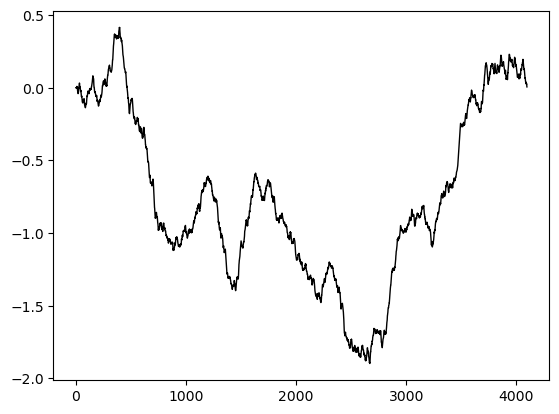

In [14]:
Level = 12
N = 2**Level
X = FBM_FF(0.8, Level)
plt.plot(X, "-k", lw=1)
plt.axis(True)

plt.show()